Objective

The objective of this notebook is to improve the performance of the best regression model by tuning its hyperparameters using GridSearchCV and building a Pipeline for streamlined preprocessing and model training.


Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# Model
from sklearn.ensemble import RandomForestRegressor

# Model Selection
from sklearn.model_selection import GridSearchCV

# Pipeline
from sklearn.pipeline import Pipeline

# Scaler
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib


Load Training and Testing Data

In [2]:
X_train = pd.read_csv("../data/X_train_scaled.csv")
X_test = pd.read_csv("../data/X_test_scaled.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

Verify Dataset

In [3]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(15751, 5)
(3938, 5)
(15751,)
(3938,)


Create Pipeline

In [4]:
pipeline = Pipeline([
    ('model', RandomForestRegressor(random_state=42))
])


 Define Hyperparameter Grid

In [5]:

param_grid = {

    'model__n_estimators': [100, 200],

    'model__max_depth': [10, 20, None],

    'model__min_samples_split': [2, 5],

    'model__min_samples_leaf': [1, 2],

    'model__max_features': ['sqrt', 'log2']

}

Perform GridSearchCV

In [6]:
grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1,

    verbose=2

)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.S

Best Parameters

In [8]:
print("Best Parameters:")

print(grid_search.best_params_)



Best Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


Best Cross-Validation Score

In [9]:
print("Best Cross Validation Score:")

print(grid_search.best_score_)

Best Cross Validation Score:
0.9730590686764705


Best Model

In [10]:
best_model = grid_search.best_estimator_

print(best_model)

Pipeline(steps=[('model',
                 RandomForestRegressor(max_features='sqrt', n_estimators=200,
                                       random_state=42))])


Predict on Test Data

In [11]:
y_pred = best_model.predict(X_test)

Model Evaluation

In [12]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 0.13418736947944296
MSE : 0.06018348132754673
RMSE : 0.24532321807677873
R2 Score : 0.9777323008449481


Actual vs Predicted Plot

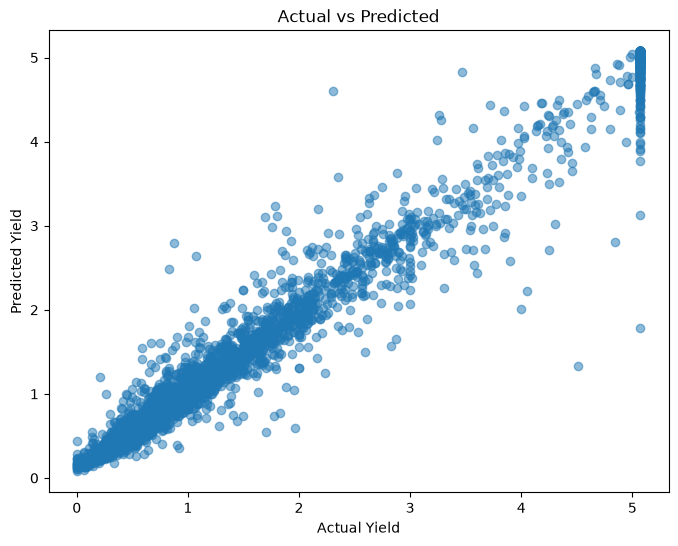

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted")

plt.show()

Residual Plot

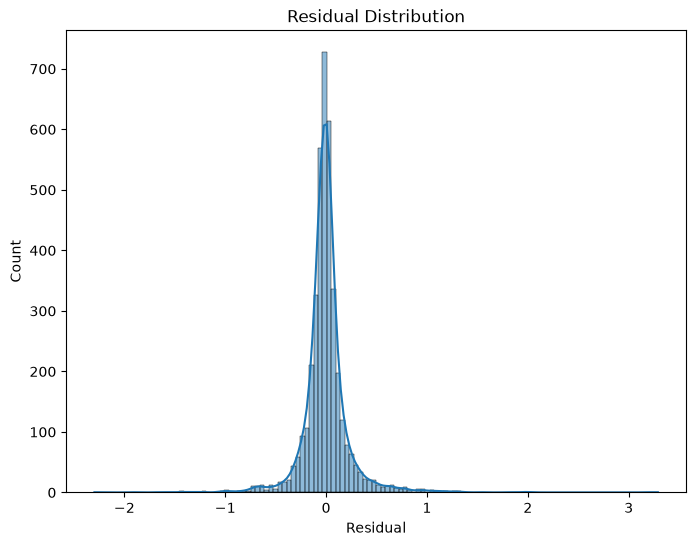

In [14]:
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

Feature Importance

In [15]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.named_steps['model'].feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Production,0.526811
1,Area,0.153032
2,Season,0.131266
3,Fertilizer,0.109857
4,Fertilizer_per_Area,0.079033


Plot Feature Importance

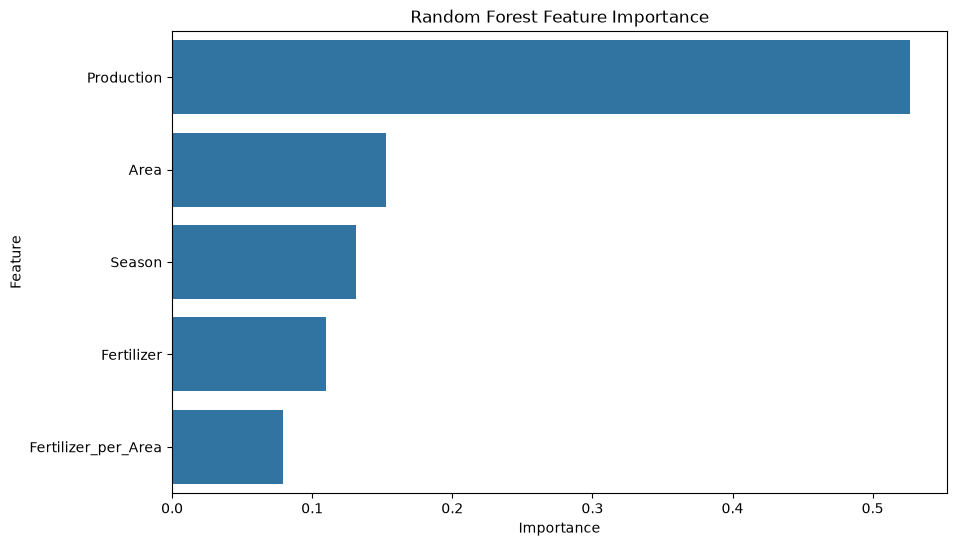

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Random Forest Feature Importance")

plt.show()

Save Tuned Model

In [17]:
from pathlib import Path

# Current notebook location
print(Path.cwd())

# If notebook is in notebooks/
project_root = Path.cwd().parent

data_folder = project_root / "models"
data_folder.mkdir(exist_ok=True)  # Creates the folder if it doesn't exist

joblib.dump(
    best_model,
    data_folder / "crop_yield_tuned_model.pkl"
)
print("Model Saved Successfully")

c:\Users\Ranjana\Crop_Yield_Prediction\notebooks
Model Saved Successfully


Grid Search Results

In [22]:

results = pd.DataFrame(grid_search.cv_results_)

print(results)


    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        3.351337      0.364142         0.110884        0.036911   
1        8.125859      1.829547         0.292672        0.098561   
2        4.307199      1.212116         0.122381        0.044704   
3        9.536079      0.533692         0.282140        0.072159   
4        4.149664      1.021657         0.123945        0.032982   
5       10.224468      1.792511         0.388601        0.127064   
6        4.597835      0.695359         0.112747        0.007624   
7       10.126633      1.408781         0.255931        0.052264   
8        4.932013      1.017100         0.146268        0.037484   
9       10.020496      1.304828         0.308516        0.106832   
10       4.087560      0.563895         0.105266        0.009834   
11       9.474251      2.128085         0.281154        0.092709   
12       4.641143      0.944549         0.135100        0.024313   
13       9.363241      1.857640         0.314389

 Compare Before and After Tuning

In [19]:
comparison = pd.DataFrame({

    "Metric": ["MAE","MSE","RMSE","R2"],

    "Baseline": [

        0.28,

        0.23,

        0.48,

        0.95

    ],

    "Tuned Model": [

        mae,

        mse,

        rmse,

        r2

    ]

})

comparison

,Metric,Baseline,Tuned Model
0,MAE,0.28,0.134187
1,MSE,0.23,0.060183
2,RMSE,0.48,0.245323
3,R2,0.95,0.977732


Save Comparison

Conclusion and Future Scope

This project demonstrates how machine learning can be applied to predict crop yield using agricultural, climatic, and environmental data. By comparing multiple regression algorithms, tuning hyperparameters, and selecting the best-performing model, the system provides reliable yield predictions that can support farmers, agricultural planners, and policymakers in making informed decisions. With future enhancements such as real-time weather integration, satellite data, explainable AI, and mobile deployment, the solution can evolve into a comprehensive smart agriculture decision support system.